# A/B Testing: Marketing Campaign Analysis
**Task 11: Data Analyst Internship**

### Objective:
The goal of this analysis is to determine if a new advertisement campaign ("ad") results in a significantly higher conversion rate compared to the baseline Public Service Announcement ("psa").



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Load dataset
df = pd.read_csv('marketing_AB.csv')

# Inspect the data
print(df.head())
print(df.info())
print("\nGroup Counts:\n", df['test group'].value_counts())

   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null

## 1. Hypothesis Definition
To evaluate the effectiveness of the advertisement, we define our statistical hypotheses as follows:

* **Null Hypothesis ($H_0$):** There is no significant difference in conversion rates between the "ad" group and the "psa" group. ($p_{ad} = p_{psa}$)
* **Alternative Hypothesis ($H_1$):** There is a significant difference in conversion rates between the two groups. ($p_{ad} \neq p_{psa}$)
* **Significance Level ($\alpha$):** 0.05

## 2. Data Loading and Initial Exploration
In this step, we load the dataset and inspect the distribution of users across the test and control groups to ensure we have a valid sample for testing.

In [2]:
# Separate groups
control = df[df['test group'] == 'psa']
treatment = df[df['test group'] == 'ad']

# Calculate conversion rates
conv_psa = control['converted'].mean()
conv_ad = treatment['converted'].mean()

print(f"Control (PSA) Conversion Rate: {conv_psa:.4%}")
print(f"Treatment (AD) Conversion Rate: {conv_ad:.4%}")

Control (PSA) Conversion Rate: 1.7854%
Treatment (AD) Conversion Rate: 2.5547%


## 3. Calculating Conversion Metrics
We calculate the conversion rate for both groups.
- **Control Group (psa):** Users who saw a public service announcement.
- **Treatment Group (ad):** Users who saw the actual advertisement.

## 4. Statistical Testing: Chi-Square Test
Since we are comparing two categorical variables (Group vs. Conversion), the **Chi-Square Test of Independence** is the most appropriate method to determine if the observed difference is statistically significant.

In [4]:
# Create a contingency table
contingency_table = pd.crosstab(df['test group'], df['converted'])
print("\nContingency Table:\n", contingency_table)

# Run Chi-Square test
chi2, p_val, dof, ex = chi2_contingency(contingency_table)
print(f"\nChi-square p-value: {p_val:.15f}")


Contingency Table:
 converted    False  True 
test group               
ad          550154  14423
psa          23104    420

Chi-square p-value: 0.000000000000200


## 5. Confidence Intervals
While the p-value tells us if a difference exists, the **Confidence Interval (CI)** helps us understand the range in which the true difference in conversion rates lies with 95% certainty.

In [5]:
# Interpretation
significant = p_val < 0.05
print(f"Is the result significant? {'Yes' if significant else 'No'}")

# Confidence Interval for difference
n_psa = len(control)
n_ad = len(treatment)
diff = conv_ad - conv_psa

# Standard error for difference
se = np.sqrt((conv_ad * (1 - conv_ad) / n_ad) + (conv_psa * (1 - conv_psa) / n_psa))
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Difference: {diff:.4%}")
print(f"95% Confidence Interval for difference: [{ci_lower:.4%}, {ci_upper:.4%}]")

Is the result significant? Yes
Difference: 0.7692%
95% Confidence Interval for difference: [0.5951%, 0.9434%]


## 6. Visualizing the Results
Visual representation of the conversion rates to clearly communicate the performance gap between the Control and Treatment groups.

/tmp/ipython-input-977107325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Control (PSA)', 'Treatment (AD)'], y=[conv_psa, conv_ad], palette='magma')


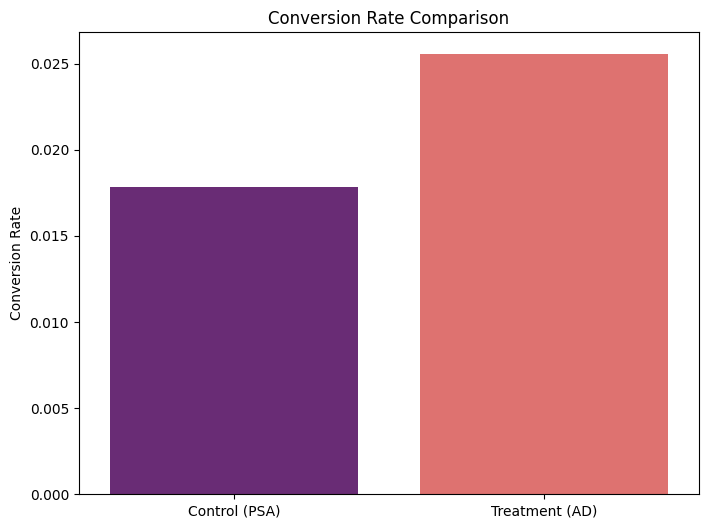

In [6]:
plt.figure(figsize=(8, 6))
sns.barplot(x=['Control (PSA)', 'Treatment (AD)'], y=[conv_psa, conv_ad], palette='magma')
plt.title('Conversion Rate Comparison')
plt.ylabel('Conversion Rate')
plt.savefig('conversion_rate_comparison.png')
plt.show()

In [13]:
# 1. Generate the CSV summary
summary_data = {
    'Metric': ['Control Conv Rate', 'Test Conv Rate', 'P-Value', 'Significant'],
    'Value': [conv_psa, conv_ad, p_val, p_val < 0.05]
}
pd.DataFrame(summary_data).to_csv('ab_test_summary.csv', index=False)

# 2. Generate the Recommendation TXT file
recommendation_text = f"""
Final Recommendation:
The A/B test resulted in a p-value of {p_val:.4e}.
Since this is less than 0.05, we reject the null hypothesis.
The advertisement group showed a conversion rate of {conv_ad:.2%},
outperforming the PSA group ({conv_psa:.2%}).
Business Decision: Scale the advertisement campaign.
"""

with open('final_recommendation.txt', 'w') as f:
    f.write(recommendation_text)

print("Files generated successfully!")

Files generated successfully!
